# 04b — ModernBERT-base Deep Learning Baseline

**Goal**: Fine-tune `answerdotai/ModernBERT-base` (149 M params) on the 10-class CFPB product classification task and compare against both the TF-IDF + Logistic Regression baseline (Macro-F1 = 0.7543) and the DeBERTa-v3-base baseline (NB04a).

**Why ModernBERT?** Released Dec 2024, ModernBERT modernises the BERT encoder with:
- **8192-token context** (vs 512 for BERT/DeBERTa) — useful for long complaints
- Rotary Positional Embeddings (RoPE), GeGLU activations, Flash Attention 2
- Trained on 2 T tokens — more pre-training data than DeBERTa-v3
- Competitive or better than DeBERTa on classification benchmarks

**Hardware target**: NVIDIA RTX 4060 8 GB VRAM · 64 GB RAM · AMD Ryzen 7000 · Windows 11

**Windows-specific fixes applied**:
- `attn_implementation="eager"` — Flash Attention 2 is **not available** on Windows
- `bf16=True` — ModernBERT was pretrained with bf16; fp16 loss scaling can cause NaN
- `dataloader_num_workers=0` — Windows spawn multiprocessing freeze
- `use_reentrant=False` — PyTorch 2.x gradient checkpointing compatibility

| Setting | Value | Rationale |
|---|---|---|
| Model | `ModernBERT-base` (149 M params) | Larger than DeBERTa-v3-base but still fits in 8 GB |
| Max tokens | 256 | Keeps VRAM safe; ModernBERT *can* go to 8192 if you have the memory |
| Batch size | 16 × 2 grad-accum = effective 32 | Same as DeBERTa notebook for fair comparison |
| Precision | **bf16** (native on Ada Lovelace) | ModernBERT-specific; avoids fp16 NaN issues |
| Attention | **eager** (not Flash Attention) | Flash Attention not available on Windows |
| Grad checkpointing | On (use_reentrant=False) | Essential — 149 M params on 8 GB |

In [ ]:
# ─── One-time installs (restart kernel after first run) ───
# ModernBERT requires transformers >= 4.48.0
# !pip install --upgrade transformers[torch] datasets accelerate evaluate scikit-learn --quiet
# !pip install sentencepiece protobuf --quiet

In [1]:
import os, sys, time, json, pickle, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# ─── Reproducibility ───
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ─── Version gate ───
tf_version = tuple(int(x) for x in transformers.__version__.split(".")[:2])
if tf_version < (4, 48):
    raise RuntimeError(
        f"ModernBERT requires transformers >= 4.48.0, got {transformers.__version__}. "
        f"Run: pip install --upgrade transformers"
    )

# ─── Device check ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    bf16_ok = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}  ({gpu_mem:.1f} GB)  bf16={'✓' if bf16_ok else '✗'}")
    if not bf16_ok:
        print("⚠️  bf16 not supported — will fall back to fp16")
else:
    print("⚠️  No GPU detected — training will be very slow")
    bf16_ok = False
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"OS: {sys.platform}")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU  (8.0 GB)  bf16=✓
Device: cuda
PyTorch: 2.10.0+cu126
Transformers: 5.3.0
OS: win32


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — adjust these knobs for your run               ║
# ╚══════════════════════════════════════════════════════════════════╝

MODEL_NAME       = "answerdotai/ModernBERT-base"
MAX_SEQ_LEN      = 256       # ModernBERT supports up to 8192, but 256 is VRAM-safe
BATCH_SIZE       = 16        # per-device
GRAD_ACCUM       = 2         # effective batch = 16 × 2 = 32
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1
NUM_EPOCHS       = 3
GRAD_CHECKPOINT  = True      # essential for 149 M params on 8 GB

# ── Precision ──
# ModernBERT was pretrained with bf16. Using fp16 can cause NaN due to
# loss scaling issues. RTX 4060 (Ada Lovelace) supports bf16 natively.
# If your GPU doesn't support bf16, we fall back to fp16.
USE_BF16 = bf16_ok           # True on RTX 4060
USE_FP16 = not bf16_ok       # fallback only

# ── Windows-safe dataloader ──
NUM_WORKERS = 0 if sys.platform == "win32" else 4

# Data sampling
MAX_TRAIN_SAMPLES = 100_000
MAX_VAL_SAMPLES   = 20_000

# Paths
ROOT       = Path("..").resolve()
PROCESSED  = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "models" / "modernbert_base"
FIG_DIR    = ROOT / "reports" / "figures" / "nb04b"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root:        {ROOT}")
print(f"Processed:   {PROCESSED}")
print(f"Output:      {OUTPUT_DIR}")
print(f"Figures:     {FIG_DIR}")
print(f"Precision:   {'bf16' if USE_BF16 else 'fp16'}")
print(f"Num workers: {NUM_WORKERS}")

Root:        C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project
Processed:   C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed
Output:      C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\modernbert_base
Figures:     C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb04b
Precision:   bf16
Num workers: 0


## 1 · Load Data

In [3]:
train_df = pd.read_parquet(PROCESSED / "train.parquet")
val_df   = pd.read_parquet(PROCESSED / "val.parquet")

with open(PROCESSED / "label_encoders.pkl", "rb") as f:
    label_encoders = pickle.load(f)

product_names = list(label_encoders["product_encoder"].classes_)
n_classes = len(product_names)

SHORT = {
    "Credit reporting or other personal consumer reports": "Credit Report",
    "Debt collection": "Debt Collect",
    "Credit card": "Credit Card",
    "Checking or savings account": "Bank Acct",
    "Mortgage": "Mortgage",
    "Money transfer, virtual currency, or money service": "Money Xfer",
    "Student loan": "Student Loan",
    "Vehicle loan or lease": "Vehicle Loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday/Pers",
    "Debt or credit management": "Debt Mgmt",
}
short_labels = [SHORT.get(n, n) for n in product_names]

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Classes: {n_classes}")
for i, sl in enumerate(short_labels):
    n_tr = (train_df["product_id"] == i).sum()
    n_va = (val_df["product_id"] == i).sum()
    print(f"  {i}: {sl:15s}  train={n_tr:>8,}  val={n_va:>6,}")

Train: 1,813,849  |  Val: 331,178  |  Classes: 10
  0: Bank Acct        train= 129,869  val=25,499
  1: Credit Card      train= 168,930  val=20,499
  2: Credit Report    train= 956,601  val=194,694
  3: Debt Collect     train= 266,081  val=37,301
  4: Debt Mgmt        train=   1,846  val= 1,362
  5: Money Xfer       train=  48,354  val=29,427
  6: Mortgage         train= 124,631  val= 6,787
  7: Payday/Pers      train=  34,581  val= 3,418
  8: Student Loan     train=  47,768  val= 6,820
  9: Vehicle Loan     train=  35,188  val= 5,371


## 2 · Stratified Sampling

In [4]:
def stratified_sample(df, max_samples, seed=42):
    if max_samples is None or len(df) <= max_samples:
        print(f"  Using all {len(df):,} rows")
        return df.copy()
    frac = max_samples / len(df)
    sampled = df.groupby("product_id", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )
    print(f"  Sampled {len(sampled):,} / {len(df):,} rows ({frac:.1%})")
    return sampled.reset_index(drop=True)


print("Train split:")
train_sub = stratified_sample(train_df, MAX_TRAIN_SAMPLES)
print("Val split:")
val_sub = stratified_sample(val_df, MAX_VAL_SAMPLES)

del train_df, val_df
gc.collect()

Train split:
  Sampled 100,000 / 1,813,849 rows (5.5%)
Val split:
  Sampled 20,000 / 331,178 rows (6.0%)


60

## 3 · Tokenisation & Dataset

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {tokenizer.__class__.__name__}  vocab={tokenizer.vocab_size:,}")


class ComplaintDataset(Dataset):
    """Lazy tokenisation dataset — avoids storing all token IDs in RAM.

    Note: ModernBERT does NOT use token_type_ids. We only return
    input_ids + attention_mask + labels.
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_texts  = train_sub["narrative"].fillna("").tolist()
train_labels = train_sub["product_id"].values.tolist()
val_texts    = val_sub["narrative"].fillna("").tolist()
val_labels   = val_sub["product_id"].values.tolist()

train_dataset = ComplaintDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
val_dataset   = ComplaintDataset(val_texts,   val_labels,   tokenizer, MAX_SEQ_LEN)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Val dataset:   {len(val_dataset):,}")

# Sanity check
sample = train_dataset[0]
print(f"Sample keys:     {list(sample.keys())}")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"label: {sample['labels'].item()} → {short_labels[sample['labels'].item()]}")

Tokenizer: TokenizersBackend  vocab=50,280
Train dataset: 100,000
Val dataset:   20,000
Sample keys:     ['input_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([256])
label: 0 → Bank Acct


## 4 · Class-Weighted Loss

Same fix as DeBERTa notebook: weights created lazily on the correct device inside `compute_loss`.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(n_classes),
    y=train_labels,
)
print("Class weights:")
for i, (sl, w) in enumerate(zip(short_labels, class_weights)):
    print(f"  {sl:15s}  {w:.4f}")


class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy loss.
    Weights are lazily moved to the correct device on first forward pass."""

    def __init__(self, class_weights_np, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._cw_np = class_weights_np
        self._cw_tensor = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self._cw_tensor is None or self._cw_tensor.device != logits.device:
            self._cw_tensor = torch.tensor(
                self._cw_np, dtype=torch.float32, device=logits.device
            )

        loss = nn.CrossEntropyLoss(weight=self._cw_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights:
  Bank Acct        1.3966
  Credit Card      1.0738
  Credit Report    0.1896
  Debt Collect     0.6817
  Debt Mgmt        98.0392
  Money Xfer       3.7509
  Mortgage         1.4554
  Payday/Pers      5.2466
  Student Loan     3.7965
  Vehicle Loan     5.1546


## 5 · Load Model

**Critical Windows fix**: ModernBERT defaults to Flash Attention 2, which is not installable on Windows.
We force `attn_implementation="eager"` to use standard PyTorch attention instead.

In [7]:
# FIX: ModernBERT defaults to Flash Attention 2, which is NOT available on Windows.
# On Windows, we force "eager" attention. On Linux with flash_attn installed, you can
# use "flash_attention_2" for ~25% speedup, or "sdpa" for PyTorch 2.x native attention.
if sys.platform == "win32":
    attn_impl = "eager"
    print(f"Windows detected → using attn_implementation='{attn_impl}'")
    print("  (Flash Attention 2 is not available on Windows)")
else:
    # On Linux, try SDPA first (PyTorch native, no extra install needed)
    attn_impl = "sdpa"
    print(f"Linux detected → using attn_implementation='{attn_impl}'")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=n_classes,
    problem_type="single_label_classification",
    attn_implementation=attn_impl,              # FIX: no flash_attn on Windows
)

if GRAD_CHECKPOINT:
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}  # FIX: PyTorch 2.x
    )
    print("✓ Gradient checkpointing enabled (use_reentrant=False)")

n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Model: {MODEL_NAME}")
print(f"  Total params:      {n_params:.1f} M")
print(f"  Trainable params:  {n_train:.1f} M")

Windows detected → using attn_implementation='eager'
  (Flash Attention 2 is not available on Windows)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Gradient checkpointing enabled (use_reentrant=False)
Model: answerdotai/ModernBERT-base
  Total params:      149.6 M
  Trainable params:  149.6 M


## 6 · Metrics

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    accuracy = (preds == labels).mean()
    return {"macro_f1": macro_f1, "accuracy": accuracy}

## 7 · Training

In [9]:
steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
eval_steps = max(steps_per_epoch // 2, 100)
save_steps = eval_steps

print(f"Steps/epoch: ~{steps_per_epoch:,}  |  Eval every {eval_steps:,} steps")
print(f"Precision: {'bf16' if USE_BF16 else 'fp16'}")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),

    # ── Schedule ──
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",

    # ── Batching ──
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,

    # ── Precision ──
    # FIX: ModernBERT pretrained with bf16; fp16 can cause NaN via loss scaling
    bf16=USE_BF16,
    fp16=USE_FP16,

    # ── Evaluation & saving ──
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=save_steps,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # ── Logging ──
    logging_steps=max(steps_per_epoch // 10, 50),
    report_to="none",

    # ── Misc ──
    seed=SEED,
    dataloader_num_workers=NUM_WORKERS,        # FIX: 0 on Windows
    dataloader_pin_memory=(NUM_WORKERS > 0),   # only useful with workers
)

trainer = WeightedTrainer(
    class_weights_np=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Steps/epoch: ~3,125  |  Eval every 1,562 steps
Precision: bf16


In [10]:
print(f"{'='*60}")
print(f"  STARTING TRAINING — {MODEL_NAME}")
print(f"  {len(train_dataset):,} train · {len(val_dataset):,} val · {NUM_EPOCHS} epochs")
print(f"  Workers: {NUM_WORKERS}  |  Precision: {'bf16' if USE_BF16 else 'fp16'}  |  Attn: {attn_impl}")
print(f"{'='*60}")

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f"\nTraining complete in {elapsed/60:.1f} min")
print(f"  Final train loss: {train_result.training_loss:.4f}")

# ─── Verify training didn't silently fail ───
logs = [l for l in trainer.state.log_history if "eval_macro_f1" in l]
if len(logs) == 0:
    print("⚠️  WARNING: No eval metrics logged — something went wrong!")
else:
    best = max(logs, key=lambda x: x["eval_macro_f1"])
    print(f"  Best eval macro-F1: {best['eval_macro_f1']:.4f} at step {best['step']}")
    print(f"  Best eval loss:     {best.get('eval_loss', 'N/A')}")
    if any(l.get("eval_loss", 0) != l.get("eval_loss", 0) for l in logs):
        print("  🔴 WARNING: NaN detected in eval loss!")

  STARTING TRAINING — answerdotai/ModernBERT-base
  100,000 train · 20,000 val · 3 epochs
  Workers: 0  |  Precision: bf16  |  Attn: eager


Step,Training Loss,Validation Loss,Macro F1,Accuracy
1562,1.576170,0.597642,0.632060,0.818350
3124,1.344360,0.549488,0.671264,0.827450
4686,1.106082,0.597727,0.662610,0.825550
6248,0.982503,0.546261,0.684105,0.833050
7810,0.595726,0.540701,0.698474,0.843300
9372,0.560400,0.528496,0.699620,0.846050


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete in 158.7 min
  Final train loss: 1.1826
  Best eval macro-F1: 0.6996 at step 9372
  Best eval loss:     0.5284964442253113


## 8 · Evaluation on Validation Set

In [11]:
print("Evaluating best checkpoint on validation set...")
predictions = trainer.predict(val_dataset)
logits = predictions.predictions
y_true = predictions.label_ids
y_pred = np.argmax(logits, axis=-1)
y_prob = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()

# ─── Sanity checks ───
assert y_true is not None, "label_ids is None — compute_loss may have broken label flow"
assert not np.isnan(logits).any(), "NaN in logits — training diverged"
assert len(np.unique(y_pred)) > 1, "Model predicts only one class — training failed"

macro_f1  = f1_score(y_true, y_pred, average="macro")
micro_f1  = f1_score(y_true, y_pred, average="micro")
weighted  = f1_score(y_true, y_pred, average="weighted")
accuracy  = (y_true == y_pred).mean()

print(f"\n{'='*50}")
print(f"  ModernBERT-base  Val Results")
print(f"{'='*50}")
print(f"  Macro-F1:    {macro_f1:.4f}")
print(f"  Micro-F1:    {micro_f1:.4f}")
print(f"  Weighted-F1: {weighted:.4f}")
print(f"  Accuracy:    {accuracy:.4f}")
print(f"{'='*50}")

print(f"\n  LogReg baseline Macro-F1:   0.7543")
print(f"  ModernBERT improvement:     {macro_f1 - 0.7543:+.4f}")
print()
print(classification_report(y_true, y_pred, target_names=short_labels, digits=3))

Evaluating best checkpoint on validation set...



  ModernBERT-base  Val Results
  Macro-F1:    0.6996
  Micro-F1:    0.8460
  Weighted-F1: 0.8497
  Accuracy:    0.8460

  LogReg baseline Macro-F1:   0.7543
  ModernBERT improvement:     -0.0547

               precision    recall  f1-score   support

    Bank Acct      0.806     0.806     0.806      1540
  Credit Card      0.655     0.765     0.706      1238
Credit Report      0.945     0.884     0.913     11758
 Debt Collect      0.659     0.761     0.706      2253
    Debt Mgmt      0.478     0.134     0.210        82
   Money Xfer      0.893     0.860     0.876      1777
     Mortgage      0.795     0.880     0.836       410
  Payday/Pers      0.485     0.631     0.549       206
 Student Loan      0.649     0.862     0.740       412
 Vehicle Loan      0.578     0.753     0.654       324

     accuracy                          0.846     20000
    macro avg      0.695     0.734     0.700     20000
 weighted avg      0.858     0.846     0.850     20000



## 9 · Confusion Matrix

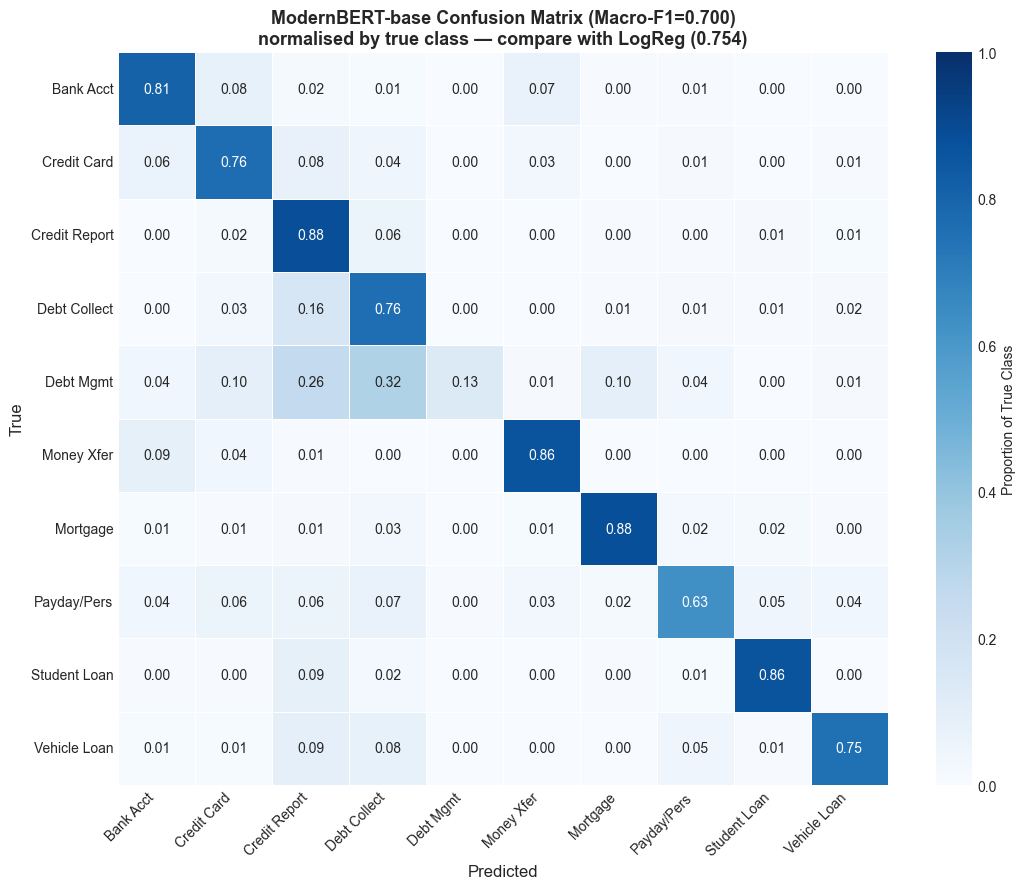

Top confused class pairs (off-diagonal > 0.05):
  Debt Mgmt       → Debt Collect     31.7%  🔴 SEVERE
  Debt Mgmt       → Credit Report    25.6%  🔴 SEVERE
  Debt Collect    → Credit Report    16.3%  🔴 SEVERE
  Debt Mgmt       → Mortgage         9.8%  🟡 Notable
  Debt Mgmt       → Credit Card      9.8%  🟡 Notable
  Vehicle Loan    → Credit Report    9.3%  🟡 Notable
  Student Loan    → Credit Report    9.0%  🟡 Notable
  Money Xfer      → Bank Acct        8.9%  🟡 Notable
  Bank Acct       → Credit Card      8.1%  🟡 Notable
  Vehicle Loan    → Debt Collect     8.0%  🟡 Notable
  Credit Card     → Credit Report    7.5%  
  Payday/Pers     → Debt Collect     7.3%  
  Bank Acct       → Money Xfer       7.2%  
  Credit Card     → Bank Acct        6.4%  
  Credit Report   → Debt Collect     6.2%  
  Payday/Pers     → Credit Report    5.8%  
  Payday/Pers     → Credit Card      5.8%  


In [12]:
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="Blues", ax=ax, linewidths=0.5, linecolor="white",
    vmin=0, vmax=1.0,
    cbar_kws={"label": "Proportion of True Class"},
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"ModernBERT-base Confusion Matrix (Macro-F1={macro_f1:.3f})\n"
    f"normalised by true class — compare with LogReg (0.754)",
    fontsize=13, fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "modernbert_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top confused class pairs (off-diagonal > 0.05):")
confused = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0.05:
            confused.append((cm[i, j], short_labels[i], short_labels[j]))
confused.sort(reverse=True)
for rate, true_cls, pred_cls in confused:
    severity = "🔴 SEVERE" if rate > 0.15 else "🟡 Notable" if rate > 0.08 else ""
    print(f"  {true_cls:15s} → {pred_cls:15s}  {rate:.1%}  {severity}")

## 10 · Three-Way Comparison: LogReg vs DeBERTa vs ModernBERT

In [13]:
# ─── Load prior results ───
logreg_results_path = PROCESSED / "class_separability_analysis.json"
deberta_results_path = ROOT / "models" / "deberta_v3_base" / "deberta_results.json"

if logreg_results_path.exists():
    with open(logreg_results_path) as f:
        logreg_data = json.load(f)
    logreg_f1 = logreg_data["per_class_f1_logreg"]
    logreg_macro = logreg_data["logreg_macro_f1"]
else:
    logreg_f1 = {sl: None for sl in short_labels}
    logreg_macro = 0.7543

if deberta_results_path.exists():
    with open(deberta_results_path) as f:
        deberta_data = json.load(f)
    deberta_f1 = deberta_data["per_class_f1"]
    deberta_macro = deberta_data["macro_f1"]
else:
    deberta_f1 = {sl: None for sl in short_labels}
    deberta_macro = None

modernbert_per_class_f1 = f1_score(y_true, y_pred, average=None)

print(f"{'Class':15s}  {'LogReg':>8s}  {'DeBERTa':>8s}  {'ModBERT':>8s}  {'Best':>8s}")
print("-" * 60)
for i, sl in enumerate(short_labels):
    lr = logreg_f1.get(sl)
    db = deberta_f1.get(sl)
    mb = modernbert_per_class_f1[i]

    vals = {}
    if lr is not None: vals["LogReg"] = lr
    if db is not None: vals["DeBERTa"] = db
    vals["ModBERT"] = mb

    best = max(vals, key=vals.get)
    lr_s = f"{lr:.3f}" if lr is not None else "N/A"
    db_s = f"{db:.3f}" if db is not None else "N/A"
    print(f"{sl:15s}  {lr_s:>8s}  {db_s:>8s}  {mb:>8.3f}  {best:>8s}")

print("-" * 60)
db_macro_s = f"{deberta_macro:.4f}" if deberta_macro is not None else "N/A"
print(f"{'Macro':15s}  {logreg_macro:>8.4f}  {db_macro_s:>8s}  {macro_f1:>8.4f}")

Class              LogReg   DeBERTa   ModBERT      Best
------------------------------------------------------------
Bank Acct           0.777       N/A     0.806   ModBERT
Credit Card         0.747       N/A     0.706    LogReg
Credit Report       0.731       N/A     0.913   ModBERT
Debt Collect        0.672       N/A     0.706   ModBERT
Debt Mgmt           0.474       N/A     0.210    LogReg
Money Xfer          0.838       N/A     0.876   ModBERT
Mortgage            0.906       N/A     0.836    LogReg
Payday/Pers         0.693       N/A     0.549    LogReg
Student Loan        0.894       N/A     0.740    LogReg
Vehicle Loan        0.811       N/A     0.654    LogReg
------------------------------------------------------------
Macro              0.7543       N/A    0.6996


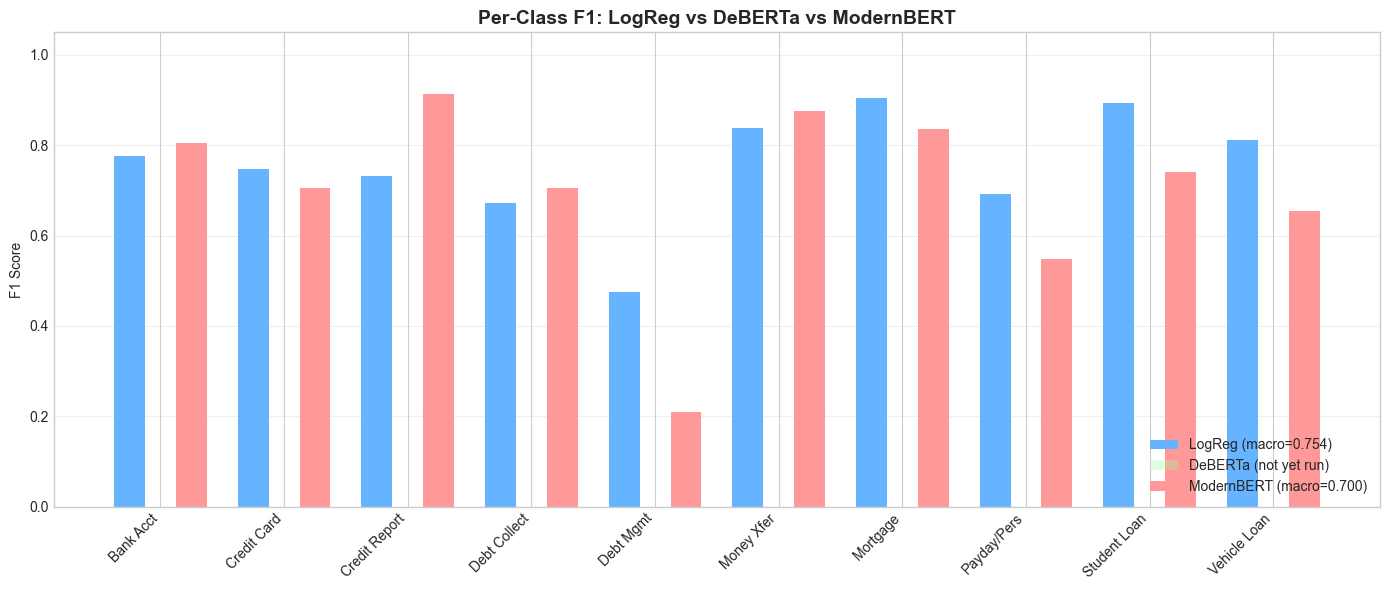

In [14]:
# ─── Grouped bar chart ───
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(n_classes)
width = 0.25

lr_vals = [logreg_f1.get(sl, 0) or 0 for sl in short_labels]
ax.bar(x - width, lr_vals, width, label=f"LogReg (macro={logreg_macro:.3f})", color="#66b3ff")

if deberta_macro is not None:
    db_vals = [deberta_f1.get(sl, 0) or 0 for sl in short_labels]
    ax.bar(x, db_vals, width, label=f"DeBERTa (macro={deberta_macro:.3f})", color="#99ff99")
else:
    ax.bar(x, [0]*n_classes, width, label="DeBERTa (not yet run)", color="#99ff99", alpha=0.3)

ax.bar(x + width, modernbert_per_class_f1, width, label=f"ModernBERT (macro={macro_f1:.3f})", color="#ff9999")

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1: LogReg vs DeBERTa vs ModernBERT", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "three_way_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10b · Training History

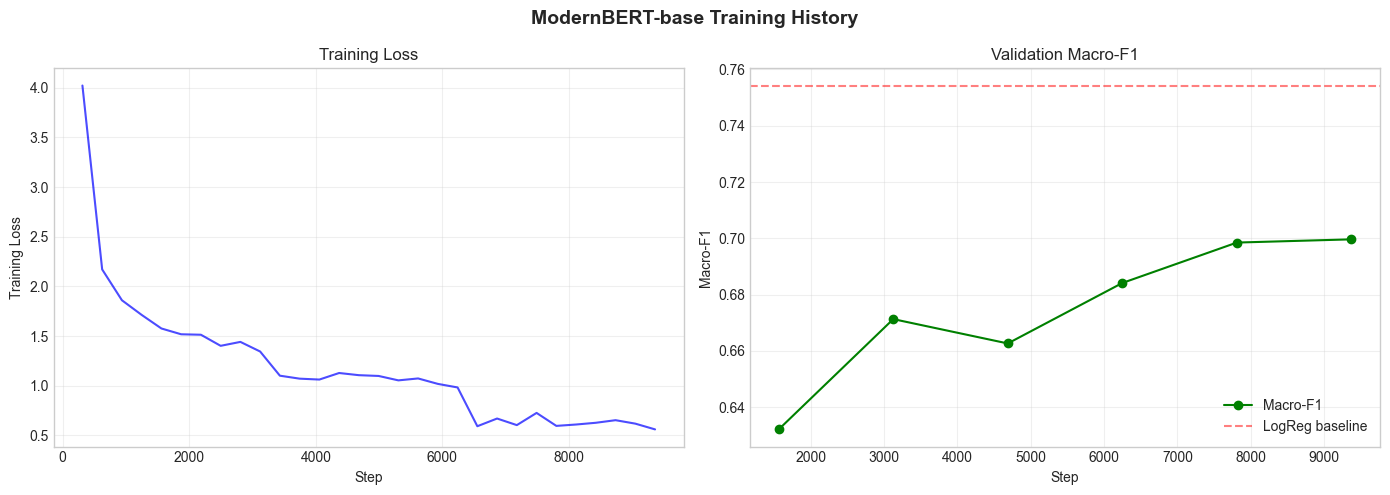

In [15]:
train_logs = [l for l in trainer.state.log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in trainer.state.log_history if "eval_macro_f1" in l]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if train_logs:
    steps = [l["step"] for l in train_logs]
    losses = [l["loss"] for l in train_logs]
    ax1.plot(steps, losses, "b-", alpha=0.7)
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Training Loss")
    ax1.set_title("Training Loss")
    ax1.grid(True, alpha=0.3)

if eval_logs:
    steps = [l["step"] for l in eval_logs]
    f1s = [l["eval_macro_f1"] for l in eval_logs]
    ax2.plot(steps, f1s, "g-o", label="Macro-F1")
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Macro-F1")
    ax2.set_title("Validation Macro-F1")
    ax2.axhline(y=0.7543, color="red", linestyle="--", alpha=0.5, label="LogReg baseline")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.suptitle("ModernBERT-base Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "modernbert_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Save Outputs

In [16]:
best_model_dir = OUTPUT_DIR / "best_model"
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))
print(f"Best model saved: {best_model_dir}")

results = {
    "model": MODEL_NAME,
    "max_seq_len": MAX_SEQ_LEN,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "epochs": NUM_EPOCHS,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
    "learning_rate": LEARNING_RATE,
    "precision": "bf16" if USE_BF16 else "fp16",
    "attn_implementation": attn_impl,
    "macro_f1": float(macro_f1),
    "micro_f1": float(micro_f1),
    "weighted_f1": float(weighted),
    "accuracy": float(accuracy),
    "per_class_f1": {sl: float(modernbert_per_class_f1[i]) for i, sl in enumerate(short_labels)},
    "confusion_matrix_normalised": cm.tolist(),
    "training_time_min": round(elapsed / 60, 1),
    "logreg_macro_f1_baseline": logreg_macro,
    "deberta_macro_f1_baseline": deberta_macro,
}

results_path = OUTPUT_DIR / "modernbert_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved: {results_path}")
print(f"Figures saved: {FIG_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\modernbert_base\best_model
Results saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\models\modernbert_base\modernbert_results.json
Figures saved: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\reports\figures\nb04b


In [17]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print("GPU memory released.")
print()
print("All three baselines complete:")
print(f"  LogReg     Macro-F1: {logreg_macro:.4f}")
if deberta_macro is not None:
    print(f"  DeBERTa    Macro-F1: {deberta_macro:.4f}")
print(f"  ModernBERT Macro-F1: {macro_f1:.4f}")

GPU memory released.

All three baselines complete:
  LogReg     Macro-F1: 0.7543
  ModernBERT Macro-F1: 0.6996
